# Convex Optimization - Homework 3
By: Adonis JAMAL

## Derive the dual problem of LASSO and format it as a Quadratic Problem.

For $w \in \mathbb{R}^d$, $X \in \mathbb{R}^{n \times d}$, $y \in \mathbb{R}^n$ and $\lambda > 0$, the LASSO problem is given by: $$\min_{w} \frac{1}{2} \|Xw - y\|_2^2 + \lambda \|w\|_1$$

Let $z \in \mathbb{R}^n$ such that $z = Xw - y$. The LASSO problem can be reformulated as: $$\min_{w, z} \frac{1}{2} \|z\|_2^2 + \lambda \|w\|_1 \quad \text{s.t.} \quad z = Xw - y$$

Let $\nu \in \mathbb{R}^n$. The Lagrangian dual function is: $$\mathcal{L}(w, z, \nu) = \frac{1}{2} \|z\|_2^2 + \lambda \|w\|_1 + \nu^T (Xw - y - z)$$

The dual is given by: $$g(\nu) = \inf_{w, z} \mathcal{L}(w, z, \nu) = -\nu^T y+ \inf_{z} \left( \frac{1}{2} \|z\|_2^2 - \nu^T z \right) + \inf_{w} \left( \lambda \|w\|_1 + (X^T \nu)^T w \right)$$

We introduce functions $g_1 : z \mapsto \frac{1}{2} \|z\|_2^2 - \nu^T z$ and $g_2 : w \mapsto \lambda \|w\|_1 + (X^T \nu)^T w$.

The function $g_1$ is convex and differentiable, with gradient $\nabla g_1(z) = z - \nu$. To find the minimum of $g_1$, we set the gradient to zero: $\nabla g_1(z) = 0 \Leftrightarrow z = \nu$. Thus, $\inf_{z} g_1(z) = g_1(\nu) = -\frac{1}{2} \|\nu\|_2^2$.

The function $g_2$ is convex but not differentiable due to the $\ell_1$ norm. Instead, note that if $\|X^T \nu \|_{\infty} > \lambda$ then the infimum is $-\infty$ by choosing $w$ such that the term is negative. If $\|X^T \nu \|_{\infty} \leq \lambda$, the infimum is attained at $w = 0$ and $\inf_{w} g_2(w) = 0$.

The dual problem is $$\max_{\nu} -\nu^T y - \frac{1}{2} \|\nu\|_2^2 \quad \text{s.t.} \quad \|X^T \nu \|_{\infty} \leq \lambda$$

This can be reformulated as a Quadratic Problem by minimizing the negative of the objective function: $$\min_{\nu} \nu^T y + \frac{1}{2} \|\nu\|_2^2 \quad \text{s.t.} \quad \|X^T \nu \|_{\infty} \leq \lambda$$

We can rewrite this in the form $\nu^T Q \nu + p^T \nu$. First, note that $\|\nu\|_2^2 = \nu^T I \nu$ where $I$ is the identity matrix. Thus, we can set $Q = \frac{1}{2} I$ and $p = y$. The constraint $\|X^T \nu \|_{\infty} \leq \lambda$ can be expressed as a set of linear inequalities: $$- \lambda \mathbf{1} \preceq X^T \nu \preceq \lambda \mathbf{1}$$
By stacking the two constraints, we get $$A \nu \preceq b$$
Where $$A = \begin{bmatrix} X^T \\ -X^T \end{bmatrix} \in \mathbb{R}^{2d \times n} \quad \text{and} \quad b = \begin{bmatrix} \lambda \mathbf{1} \\ \lambda \mathbf{1} \end{bmatrix} \in \mathbb{R}^{2d}$$

The Quadratic Problem formulation of the dual of LASSO is: $$\min_{\nu} \nu^T Q \nu + p^T \nu \quad \text{s.t.} \quad A \nu \preceq b$$




## Implement the barrier method to solve QP.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
def centering_step(Q, p, A, b, t, v0, eps):
    """
    Implements the Newton method to solve the centering step using a backtracking line search.

    Inputs:
        Q, p, A, b: parameters of the QP
        t: barrier parameter
        v0: initial variable
        eps: target precision

    Outputs:
        list: sequence of variable iterates
    """
    v = v0.copy()
    v_seq = [v.copy()]

    # Backtracking line search parameters
    # 0 < alpha < 0.5 and 0 < beta < 1
    alpha = 0.3
    beta = 0.8

    while True:
        # 1. Compute residuals and derivatives
        # slack vector, with s > 0 for the log barrier
        s = b - A @ v

        # Invert slack vector
        d = 1.0 / s

        # Gradient and Hessian
        grad = t * (2 * Q @ v + p) + A.T @ d
        Hessian = t * (2 * Q) + A.T @ (np.diag(d**2) @ A)

        # 2. Newton step
        dv_nt = np.linalg.solve(Hessian, -grad)

        # 3. Newton decrement
        lambda_sq = - grad.T @ dv_nt

        # Stopping criterion
        if lambda_sq / 2 <= eps:
            break

        # 4. Backtracking line search
        step_size = 1.0

        # Check feasibility: b - A(v + step_size * dv_nt) > 0
        while True:
            v_new = v + step_size * dv_nt
            if np.all(b - A @ v_new > 0):
                break
            step_size *= beta
        
        # Check sufficient decrease
        obj_v = t * (v.T @ Q @ v + p.T @ v) - np.sum(np.log(b - A @ v))

        while True:
            v_new = v + step_size * dv_nt
            obj_v_new = t * (v_new.T @ Q @ v_new + p.T @ v_new) - np.sum(np.log(b - A @ v_new))
            if obj_v_new <= obj_v + alpha * step_size * (grad.T @ dv_nt):
                break
            step_size *= beta

        # 5. Update
        v = v + step_size * dv_nt
        v_seq.append(v.copy())

    return v_seq

In [3]:
def barr_method(Q, p, A, b, v0, eps, mu):
    """
    Implements the barrier method to solve the QP.
    
    Inputs:
        Q, p, A, b: parameters of the QP
        v0: feasible point
        eps: precision criterion
        mu: parameter to update t

    Outputs:
        list: sequence of variable iterates
        list: sequence of precision criteria values
        list: precision criteria values for outer loop
    """
    v = v0.copy()
    v_inner = [v.copy()]
    v_outer = [v.copy()]

    # Barrier method parameters
    t = 1.0         # initial t
    m = A.shape[0]  # number of constraints
    precision = [m/t]

    while True:
        # 1. Centering step
        v_seq_center = centering_step(Q, p, A, b, t, v, eps)
        v = v_seq_center[-1]
        v_inner.extend(v_seq_center[1:])
        v_outer.append(v.copy())
        precision.append(m / t)

        # Stopping criterion
        if m / t < eps:
            break

        # 2. Update t
        t *= mu

    return v_inner, v_outer, precision

## Test functions on randomly generated matrices $X$ and observations $y$.

In [4]:
# Parameters
lam = 10.0  # Regularization parameter
n = 20      # Number of observations
d = 50      # Number of features

In [5]:
# Generate random data
np.random.seed(0)
X = np.random.randn(n, d)
y = np.random.randn(n)

# Construct Q, p, A, b for the dual of LASSO
Q = 0.5 * np.eye(n)
p = y
A = np.vstack([X.T, -X.T])
b = lam * np.ones(2 * d)

# Initial feasible point v0
v0 = np.zeros(n)

# Precision criterion
eps = 1e-6

# mu values
mu_values = [2, 15, 50, 100, 150]
results = {}

In [6]:
def cost(v):
    return v.T @ Q @ v + p.T @ v

100%|██████████| 5/5 [00:00<00:00, 72.74it/s]


Global minimum objective value found: -7.845112051680027 for mu = 15


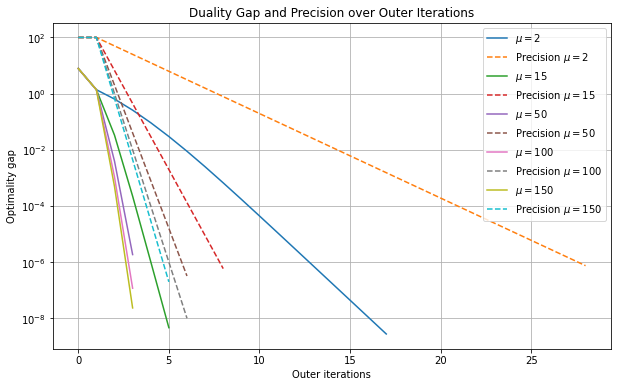

In [7]:
global_best = np.inf
# Run barrier method for different mu values
for mu in tqdm(mu_values):
    v_inner, v_outer, precision = barr_method(Q, p, A, b, v0, eps, mu)
    
    obj_values_inner = [cost(v) for v in v_inner]
    obj_values_outer = [cost(v) for v in v_outer]

    results[mu] = {'v_inner': v_inner, 'v_outer': v_outer, 'precision': precision,
                   'obj_values_inner': obj_values_inner, 'obj_values_outer': obj_values_outer}
    
    # Best objective
    current_best = np.min(obj_values_outer)
    if current_best < global_best:
        global_best = current_best
        best_v = v_outer[np.argmin(obj_values_outer)]
        best_mu = mu

print(f"Global minimum objective value found: {global_best} for mu = {best_mu}")

plt.figure(figsize=(10, 6))
for mu in mu_values:
    obj_values = results[mu]['obj_values_outer']
    gap = obj_values - global_best
    gap = gap[gap > 10e-10]

    plt.semilogy(gap, label=f'$\mu = {mu}$')
    plt.semilogy(results[mu]['precision'], '--', label=f'Precision $\mu = {mu}$')

plt.xlabel("Outer iterations")
plt.ylabel("Optimality gap")
plt.title("Duality Gap and Precision over Outer Iterations")
plt.legend()
plt.grid(True)
plt.show()

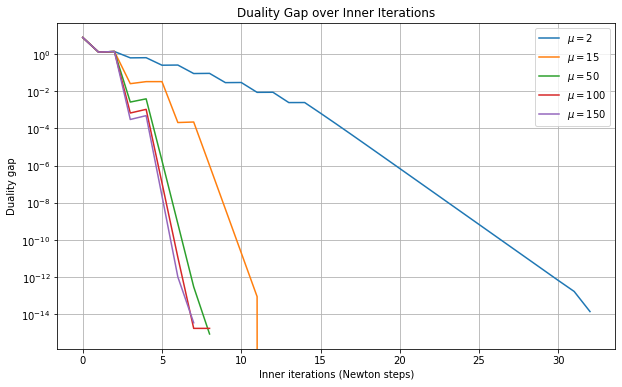

In [8]:
plt.figure(figsize=(10, 6))
for mu in mu_values:
    gap = results[mu]['obj_values_inner'] - global_best
    plt.semilogy(gap, label=f'$\mu = {mu}$')

plt.xlabel("Inner iterations (Newton steps)")
plt.ylabel("Duality gap")
plt.title("Duality Gap over Inner Iterations")
plt.legend()
plt.grid(True)
plt.show()

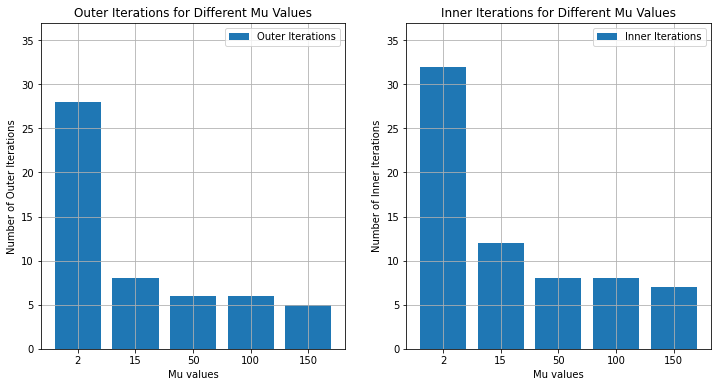

In [9]:
mus = [str(mu) for mu in mu_values]
count_inner = [len(results[mu]['obj_values_inner'])-1 for mu in mu_values]
count_outer = [len(results[mu]['obj_values_outer'])-1 for mu in mu_values]

plt.figure(figsize=(12, 6))

fig = plt.subplot(1, 2, 1)
plt.ylim(0, max(count_outer + count_inner) + 5)
plt.bar(mus, count_outer, label='Outer Iterations')
plt.xlabel("Mu values")
plt.ylabel("Number of Outer Iterations")
plt.title("Outer Iterations for Different Mu Values")
plt.grid(True)
plt.legend()

fig = plt.subplot(1, 2, 2)
plt.ylim(0, max(count_outer + count_inner) + 5)
plt.bar(mus, count_inner, label='Inner Iterations')
plt.xlabel("Mu values")
plt.ylabel("Number of Inner Iterations")
plt.title("Inner Iterations for Different Mu Values")
plt.grid(True)
plt.legend()

plt.show()

We have established in question 1 that $z = \nu$ when solving $\nabla g_1(z) = 0$. We then have $Xw - y = \nu$, which means that $$w = X^{\dagger} (\nu + y)$$ where $X^{\dagger}$ is the pseudo-inverse of $X$.

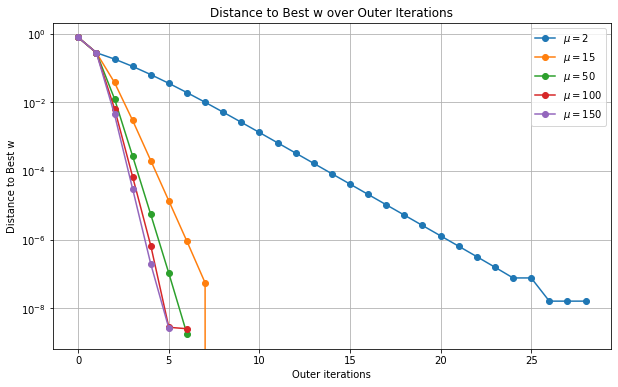

In [10]:
fig = plt.figure(figsize=(10, 6))

best_w = np.linalg.pinv(X) @ (best_v + y)

for mu in mu_values:
    omega_dist = [np.linalg.norm(np.linalg.pinv(X) @ (v + y) - best_w) for v in results[mu]['v_outer']]

    plt.semilogy(omega_dist, 'o-', label=f'$\mu = {mu}$')

plt.xlabel("Outer iterations")
plt.ylabel("Distance to Best w")
plt.title("Distance to Best w over Outer Iterations")
plt.legend()
plt.grid(True)
plt.show()

The convergencee of $w$ is approximately the same as that of $\nu$ since $X^{\dagger}$ is a linear operator. We observe linear convergence of $w$ as well.

The parameter $\mu$ controls the increase of the barrier parameter $t$ at each iteration. 

For small $\mu$, the barrier method will take small steps, leading to more iterations but potentially higher accuracy. For large $\mu$, the method will take larger steps, resulting in fewer iterations but possibly lower accuracy. 

Looking at the results, we can see that extreme values of $\mu$ (either too small or too large) are not optimal for convergence speed and accuracy. 

In order to get a good balance, we need a large enough value to reduce the duality gap quickly (fewer outer loops), but small enough that Newton's method can still converge quadratically and rapidly in the inner loops. 

We can therefore conclude that a value of $\mu$ around 15 provides a good trade-off between convergence speed and accuracy for this specific problem. This value is also the one that achieved the lowest objective value in our tests.